# A* Search

A* Search is an **informed search algorithm** that combines the actual cost from the start node with the estimated cost from the current node to the goal.

\[
f(n) = g(n) + h(n)
\]

Where:

- **\(g(n)\)**: Actual cost from the start state to node \(n\).
- **\(h(n)\)**: Estimated cost from node \(n\) to the goal.
- **\(f(n)\)**: Estimated total cost of a solution through node \(n\).

A* always expands the node with the **lowest \(f(n)\)** value.

Unlike **Greedy Best-First Search**, which considers only \(h(n)\), A* considers both the cost already incurred and the estimated future cost.

- **Tree Search:** A* is optimal if \(h(n)\) is **admissible**.

In [1]:
import heapq       # priority queue (min-heap) — like you'd build in C
import math         # for sqrt
import networkx as nx
import matplotlib.pyplot as plt
%matplotlib inline

## Step 1 — Node coordinates
Each node's (x, y) position. This is what the heuristic (straight-line distance) will be computed from.

In [2]:
nodes = {
    'Oradea': (131, 571),
    'Zerind': (108, 531),
    'Arad': (91, 492),
    'Timisoara': (94, 410),
    'Lugoj': (165, 379),
    'Mehadia': (168, 339),
    'Dobreta': (165, 299),
    'Sibiu': (207, 457),
    'Fagaras': (305, 449),
    'RimnicuVilcea': (233, 410),
    'Pitesti': (320, 368),
    'Craiova': (253, 288),
    'Bucharest': (400, 327),
    'Giurgiu': (375, 270),
    'Urziceni': (456, 350),
    'Hirsova': (534, 350),
    'Eforie': (562, 293),
    'Vaslui': (509, 444),
    'Iasi': (473, 506),
    'Neamt': (406, 537)
}

## Step 2 — Edges + weights
Each edge is represented as `(node1, node2, weight)`. The weights are the road distances in kilometres given in the Romania map.


In [3]:
edges = [
    ('Oradea', 'Zerind', 71),
    ('Oradea', 'Sibiu', 151),
    ('Zerind', 'Arad', 75),
    ('Arad', 'Sibiu', 140),
    ('Arad', 'Timisoara', 118),
    ('Timisoara', 'Lugoj', 111),
    ('Lugoj', 'Mehadia', 70),
    ('Mehadia', 'Dobreta', 75),
    ('Dobreta', 'Craiova', 120),
    ('Craiova', 'RimnicuVilcea', 146),
    ('Craiova', 'Pitesti', 138),
    ('Sibiu', 'Fagaras', 99),
    ('Sibiu', 'RimnicuVilcea', 80),
    ('RimnicuVilcea', 'Pitesti', 97),
    ('Fagaras', 'Bucharest', 211),
    ('Pitesti', 'Bucharest', 101),
    ('Bucharest', 'Giurgiu', 90),
    ('Bucharest', 'Urziceni', 85),
    ('Urziceni', 'Hirsova', 98),
    ('Urziceni', 'Vaslui', 142),
    ('Hirsova', 'Eforie', 86),
    ('Vaslui', 'Iasi', 92),
    ('Iasi', 'Neamt', 87)
]

## Step 3 — Build the adjacency list
This is exactly like building an adjacency list from an edge array in C — two explicit loops, no shortcuts.

The graph is **undirected**, so for every edge `(u, v, w)` we add an entry on both sides: add `v` to `u`'s neighbour list, and add `u` to `v`'s neighbour list.

In [4]:
def build_graph(edges):
    graph = {}   # dictionary = like a hash map / array-of-lists in C

    for u, v, w in edges:
        if u not in graph:
            graph[u] = []          # first time seeing this node, create an empty list
        if v not in graph:
            graph[v] = []

        graph[u].append((v, w))    # u -> v, cost w
        graph[v].append((u, w))    # v -> u, cost w (undirected, both directions)

    return graph

graph = build_graph(edges)

# sanity check: print the adjacency list to make sure it's correct
for node in graph:
    print(node, "->", graph[node])

Oradea -> [('Zerind', 71), ('Sibiu', 151)]
Zerind -> [('Oradea', 71), ('Arad', 75)]
Sibiu -> [('Oradea', 151), ('Arad', 140), ('Fagaras', 99), ('RimnicuVilcea', 80)]
Arad -> [('Zerind', 75), ('Sibiu', 140), ('Timisoara', 118)]
Timisoara -> [('Arad', 118), ('Lugoj', 111)]
Lugoj -> [('Timisoara', 111), ('Mehadia', 70)]
Mehadia -> [('Lugoj', 70), ('Dobreta', 75)]
Dobreta -> [('Mehadia', 75), ('Craiova', 120)]
Craiova -> [('Dobreta', 120), ('RimnicuVilcea', 146), ('Pitesti', 138)]
RimnicuVilcea -> [('Craiova', 146), ('Sibiu', 80), ('Pitesti', 97)]
Pitesti -> [('Craiova', 138), ('RimnicuVilcea', 97), ('Bucharest', 101)]
Fagaras -> [('Sibiu', 99), ('Bucharest', 211)]
Bucharest -> [('Fagaras', 211), ('Pitesti', 101), ('Giurgiu', 90), ('Urziceni', 85)]
Giurgiu -> [('Bucharest', 90)]
Urziceni -> [('Bucharest', 85), ('Hirsova', 98), ('Vaslui', 142)]
Hirsova -> [('Urziceni', 98), ('Eforie', 86)]
Vaslui -> [('Urziceni', 142), ('Iasi', 92)]
Eforie -> [('Hirsova', 86)]
Iasi -> [('Vaslui', 92), ('Nea

## Step 4 — Heuristic h(n)
The heuristic `h(n)` is the straight-line distance from a city to Bucharest. The assignment provides these heuristic values directly in `h_table`, so we use the given values rather than recalculating them from the plotting coordinates.


In [5]:
h_table = {
    'Arad': 366,
    'Bucharest': 0,
    'Craiova': 160,
    'Dobreta': 242,
    'Eforie': 161,
    'Fagaras': 176,
    'Giurgiu': 77,
    'Hirsova': 151,
    'Iasi': 226,
    'Lugoj': 244,
    'Mehadia': 241,
    'Neamt': 234,
    'Oradea': 380,
    'Pitesti': 98,
    'RimnicuVilcea': 193,
    'Sibiu': 253,
    'Timisoara': 329,
    'Urziceni': 80,
    'Vaslui': 199,
    'Zerind': 374
}

def heuristic(node, goal):
    return h_table[node]

## Helper to draw the graph
(This is only for drawing — there's no A* logic in here, just take it as-is.)

In [6]:
def draw_graph(graph, goal=None, highlight_path=None, title=""):
    G_ = nx.Graph()
    for u in graph:
        for v, w in graph[u]:
            G_.add_edge(u, v, weight=w)

    plt.figure(figsize=(8, 5.5))
    nx.draw_networkx_edges(G_, nodes, edge_color='lightgray', width=2)
    nx.draw_networkx_nodes(G_, nodes, node_color='lightblue', node_size=1500)

    labels = {}
    for n in nodes:
        if goal is not None:
            labels[n] = n + "\nh=" + str(round(heuristic(n, goal), 1))
        else:
            labels[n] = n
    nx.draw_networkx_labels(G_, nodes, labels=labels, font_size=10)

    edge_labels = nx.get_edge_attributes(G_, 'weight')
    nx.draw_networkx_edge_labels(G_, nodes, edge_labels=edge_labels, font_size=9)

    if highlight_path:
        path_edges = []
        for i in range(len(highlight_path) - 1):
            path_edges.append((highlight_path[i], highlight_path[i + 1]))

        nx.draw_networkx_edges(G_, nodes, edgelist=path_edges, edge_color='red', width=3)
        nx.draw_networkx_nodes(G_, nodes, nodelist=highlight_path, node_color='salmon', node_size=1500)
        nx.draw_networkx_nodes(G_, nodes, nodelist=[highlight_path[0]], node_color='lightgreen', node_size=1600)
        nx.draw_networkx_nodes(G_, nodes, nodelist=[highlight_path[-1]], node_color='gold', node_size=1600)

    plt.title(title)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

## Step 5 — A* Search (simple version)

Just like in C: keep a priority queue (`heapq`), and keep a `visited` set (like a `bool visited[N]` array).

Every step:
1. Pop the node with the smallest `f` value from the priority queue
2. If it's the goal — done, return the path
3. If it's already visited — skip it, move on
4. Otherwise, mark it visited, and push all of its neighbours into the queue

`f = g + h` , `g` = actual cost paid so far, `h` = estimated cost remaining to the goal.

In [7]:
def astar_search(graph, start, goal):
    # each entry in the priority queue: (f, node_name, path_so_far, g)
    pq = []
    heapq.heappush(pq, (heuristic(start, goal), start, [start], 0))

    visited = set()   # like bool visited[N] = {False} in C

    while len(pq) > 0:
        f, node, path, g = heapq.heappop(pq)

        if node == goal:
            return path, g          # found it! return the path and total cost

        if node in visited:
            continue                # already processed this node, skip

        visited.add(node)

        for neighbor, cost in graph[node]:
            if neighbor not in visited:
                new_g = g + cost
                new_f = new_g + heuristic(neighbor, goal)   # f(n) = g(n) + h(n)
                heapq.heappush(pq, (new_f, neighbor, path + [neighbor], new_g))

    return None, None   # queue is empty, no path found to the goal

## Task 1 — Run A* from Arad to Bucharest
Run A* using the given Romania graph and heuristic table.

Path: Arad -> Sibiu -> RimnicuVilcea -> Pitesti -> Bucharest
Total cost: 418


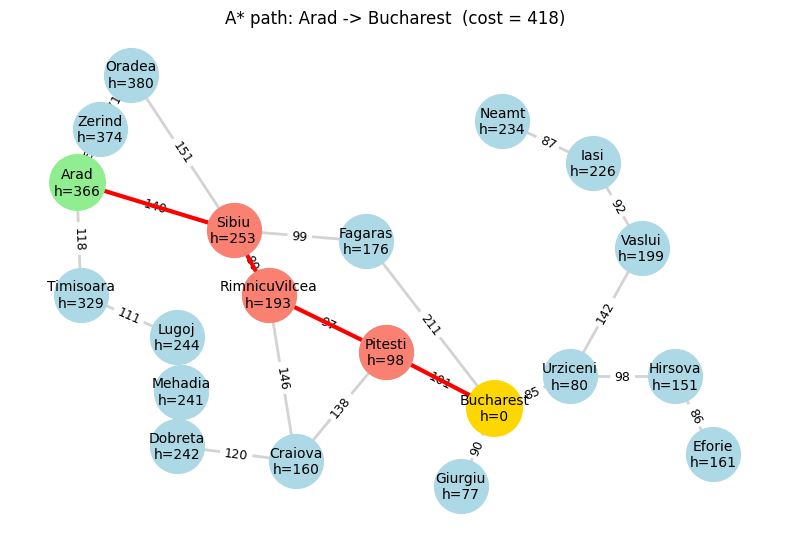

In [8]:
start = 'Arad'
goal = 'Bucharest'

path, cost = astar_search(graph, start, goal)

if path is None:
    print("No path found.")
else:
    print("Path:", " -> ".join(path))
    print("Total cost:", cost)

    draw_graph(
        graph,
        goal=goal,
        highlight_path=path,
        title="A* path: " + start + " -> " + goal +
              "  (cost = " + str(cost) + ")"
    )

In [9]:
test_starts = ['Sibiu', 'Timisoara', 'Craiova']

for start in test_starts:
    path, cost = astar_search(graph, start, 'Bucharest')

    print("Start:", start)
    print("Path:", " -> ".join(path))
    print("Total cost:", cost)
    print()

Start: Sibiu
Path: Sibiu -> RimnicuVilcea -> Pitesti -> Bucharest
Total cost: 278

Start: Timisoara
Path: Timisoara -> Arad -> Sibiu -> RimnicuVilcea -> Pitesti -> Bucharest
Total cost: 536

Start: Craiova
Path: Craiova -> Pitesti -> Bucharest
Total cost: 239



### Task 1 — Expected output for the additional states

```text
Start: Sibiu
Path: Sibiu -> RimnicuVilcea -> Pitesti -> Bucharest
Total cost: 278

Start: Timisoara
Path: Timisoara -> Arad -> Sibiu -> RimnicuVilcea -> Pitesti -> Bucharest
Total cost: 536

Start: Craiova
Path: Craiova -> Pitesti -> Bucharest
Total cost: 239
```


## Task 2 — Admissible vs Inadmissible Heuristic

A* is guaranteed to return an optimal path when the heuristic is admissible.
An admissible heuristic never overestimates the actual remaining cost to the goal.

For this task, the A* search algorithm is not changed. Instead, the heuristic
value is deliberately changed so that it becomes inadmissible.

Start: Arad
Goal: Bucharest
Path: Arad -> Sibiu -> Fagaras -> Bucharest
Total cost: 450


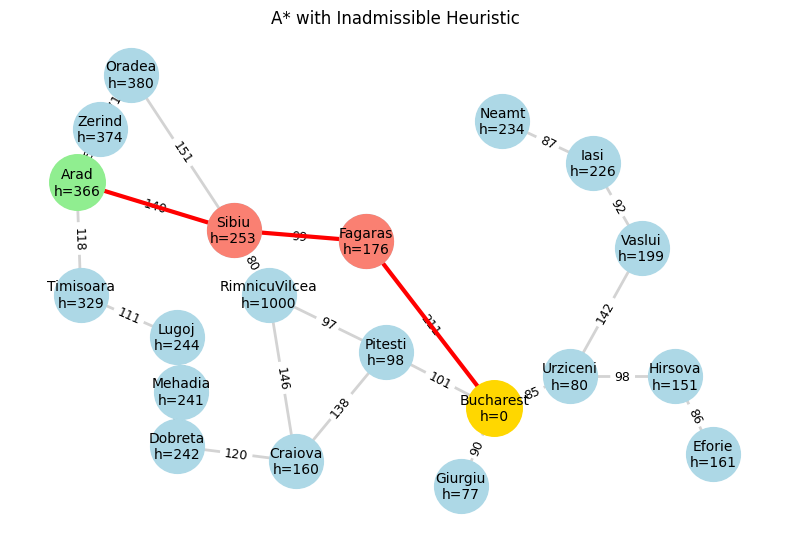

In [10]:
h_table_bad = h_table.copy()

# Actual shortest distance from RimnicuVilcea to Bucharest is:
# RimnicuVilcea -> Pitesti -> Bucharest
# 97 + 101 = 198 km
#
# Set the heuristic to 1000, which overestimates 198.
h_table_bad['RimnicuVilcea'] = 1000

# Use the bad heuristic
h_table = h_table_bad

start = 'Arad'
goal = 'Bucharest'

path, cost = astar_search(graph, start, goal)

print("Start:", start)
print("Goal:", goal)
print("Path:", " -> ".join(path))
print("Total cost:", cost)

draw_graph(
    graph,
    goal=goal,
    highlight_path=path,
    title="A* with Inadmissible Heuristic"
)

### Task 2 — Justification

The heuristic is made inadmissible by setting `h(RimnicuVilcea) = 1000`.

The actual shortest remaining cost from RimnicuVilcea to Bucharest is:

`RimnicuVilcea -> Pitesti -> Bucharest = 97 + 101 = 198 km`.

Since 1000 is greater than 198, the heuristic overestimates the true
remaining cost. Therefore the heuristic is inadmissible.

Because the heuristic is inadmissible, A* is not guaranteed to return
an optimal solution. In this run it returns:

`Arad -> Sibiu -> Fagaras -> Bucharest`

with total cost `450 km`.

The optimal path is:

`Arad -> Sibiu -> RimnicuVilcea -> Pitesti -> Bucharest`

with total cost `418 km`.

Hence, A* returns a suboptimal path in this scenario without modifying
the `astar_search()` function.


In [11]:
# Restore the original heuristic table before Task 3

h_table = {
    'Arad': 366,
    'Bucharest': 0,
    'Craiova': 160,
    'Dobreta': 242,
    'Eforie': 161,
    'Fagaras': 176,
    'Giurgiu': 77,
    'Hirsova': 151,
    'Iasi': 226,
    'Lugoj': 244,
    'Mehadia': 241,
    'Neamt': 234,
    'Oradea': 380,
    'Pitesti': 98,
    'RimnicuVilcea': 193,
    'Sibiu': 253,
    'Timisoara': 329,
    'Urziceni': 80,
    'Vaslui': 199,
    'Zerind': 374
}

## Task 3 — Greedy Best-First Search

Greedy Best-First Search selects the next node using only the heuristic
value h(n).

A* uses:

f(n) = g(n) + h(n)

Greedy Best-First Search uses:

f(n) = h(n)

The existing A* implementation is used as the base. The main change is
that the priority queue uses only h(n), instead of g(n) + h(n).

In [12]:
def greedy_best_first_search(graph, start, goal):
    # Same structure as A*; priority is h(n) only.
    pq = []
    heapq.heappush(pq, (heuristic(start, goal), start, [start], 0))

    visited = set()

    while len(pq) > 0:
        h, node, path, g = heapq.heappop(pq)

        if node == goal:
            return path, g

        if node in visited:
            continue

        visited.add(node)

        for neighbor, cost in graph[node]:
            if neighbor not in visited:
                new_g = g + cost
                new_h = heuristic(neighbor, goal)   # Greedy: use only h(n)
                heapq.heappush(
                    pq,
                    (new_h, neighbor, path + [neighbor], new_g)
                )

    return None, None


Start: Timisoara
Goal: Bucharest
Path: Timisoara -> Lugoj -> Mehadia -> Dobreta -> Craiova -> Pitesti -> Bucharest
Total cost: 615


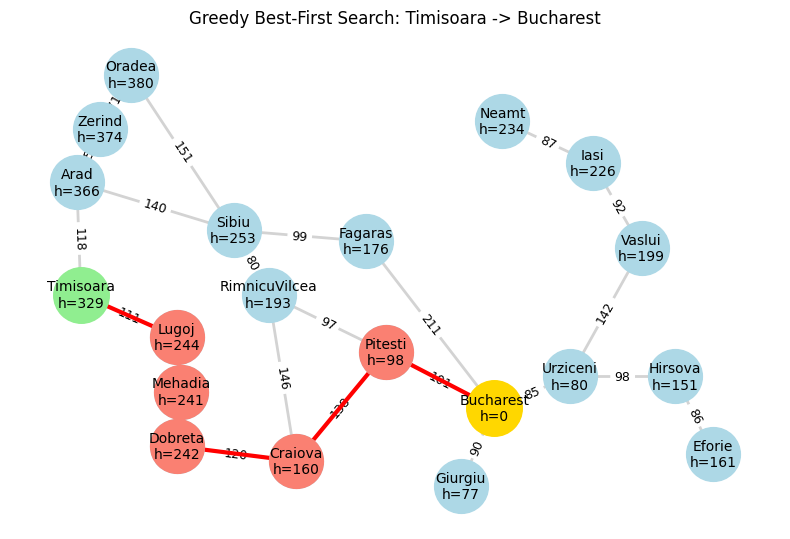

In [13]:
start = 'Timisoara'
goal = 'Bucharest'

path, cost = greedy_best_first_search(
    graph,
    start,
    goal
)

print("Start:", start)
print("Goal:", goal)

if path is None:
    print("No path found.")
else:
    print("Path:", " -> ".join(path))
    print("Total cost:", cost)

    draw_graph(
        graph,
        goal=goal,
        highlight_path=path,
        title="Greedy Best-First Search: " +
              start + " -> " + goal
    )

### Task 3.1 — Complete Scenario Justification

Start state: Timisoara

Goal state: Bucharest

Greedy Best-First Search successfully reaches Bucharest.

The returned path is:

Timisoara -> Lugoj -> Mehadia -> Dobreta -> Craiova -> Pitesti -> Bucharest

The total cost is 615 km.

Greedy Best-First Search selects nodes using only h(n), so it does not
consider the cost already travelled. Therefore, it can successfully
reach the goal but does not guarantee the shortest path.

In [14]:
# Create a separate copy of the Romania graph
incomplete_graph = {}

for node in graph:
    incomplete_graph[node] = list(graph[node])

# Remove every edge connected to Bucharest.
for node in incomplete_graph:
    incomplete_graph[node] = [
        (neighbor, cost)
        for neighbor, cost in incomplete_graph[node]
        if neighbor != 'Bucharest'
    ]

# Also clear Bucharest's own adjacency list.
incomplete_graph['Bucharest'] = []

start = 'Timisoara'
goal = 'Bucharest'

path, cost = greedy_best_first_search(
    incomplete_graph,
    start,
    goal
)

print("Start:", start)
print("Goal:", goal)

if path is None:
    print("No path found.")
else:
    print("Path:", " -> ".join(path))
    print("Total cost:", cost)


Start: Timisoara
Goal: Bucharest
No path found.


### Task 3.2 — Justification

Start state: Timisoara

Goal state: Bucharest

In this scenario, Bucharest is disconnected from the rest of the
Romania graph. Therefore there is no path from Timisoara to Bucharest.

Greedy Best-First Search explores all reachable nodes and eventually
exhausts its priority queue. It therefore returns:

`No path found.`

This demonstrates a scenario where Greedy Best-First Search does not
successfully reach the goal.

Note: with the given finite Romania graph and the `visited` set in the
provided search code, the search terminates. Therefore an actual
infinite non-termination example would require different search
conditions or an infinite/repeated-state graph.


## What is the difference between Heuristic and Heuristic Function?

**Heuristic:**  
A heuristic is an estimated cost or value that indicates how close a current state is to the goal state.

**Heuristic Function:**  
A heuristic function is the function or method used to calculate the heuristic value for a given state.

**In short:**  
**Heuristic = estimated value**  
**Heuristic Function = method used to obtain the estimated value**